In [6]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

# Se puede reemplazar por una ruta concreta, por ejemplo Path('data/scene_1.h5').
candidatos = sorted(Path('data').glob('scene_3.h5'))
if not candidatos:
    raise FileNotFoundError('No se encontró ningún archivo data/scene_*.h5')

SCENE_PATH = candidatos[0]
VIEW_ID = 0  # cambie este índice para explorar otra cámara
print(f'Escena seleccionada: {SCENE_PATH} ({SCENE_PATH.stat().st_size / 2**30:.2f} GiB en disco)')

Escena seleccionada: data/scene_3.h5 (2.96 GiB en disco)


## 1. ¿Cómo se compone la escena?

Los ejes del tensor transitorio son `[vista, alto, ancho, tiempo, canal]`. Una celda `(y, x)` no contiene un único color: contiene un histograma de intensidad para cada *bin* temporal. `images` es la imagen RGB integrada/estacionaria y `poses` contiene una transformación cámara-a-mundo por vista.

In [7]:
def gib(n_bytes):
    return n_bytes / 2**30

with h5py.File(SCENE_PATH, 'r') as f:
    print('Atributos de la escena:')
    for nombre, valor in f.attrs.items():
        print(f'  {nombre}: {valor}')

    print('\nDatasets:')
    for nombre, ds in f.items():
        logical = ds.size * ds.dtype.itemsize
        print(
            f'  {nombre:10s} shape={str(ds.shape):27s} dtype={str(ds.dtype):8s} '
            f'tamaño lógico={gib(logical):6.2f} GiB  chunks={ds.chunks}  compresión={ds.compression}'
        )

    n_views, height, width, n_bins, channels = f['transients'].shape
    assert f['images'].shape == (n_views, height, width, channels)
    assert f['poses'].shape[0] == n_views

print(
    f'\nInterpretación: {n_views} vistas × {height}×{width} píxeles × '
    f'{n_bins} bins temporales × {channels} canales.'
)

Atributos de la escena:
  channels: 3
  dtype: float32
  height: 256
  mitsuba_variant: cuda_ad_rgb
  num_sensors: 25
  pose_type: camera_to_world
  scene_id: 3
  spp: 16384
  temporal_bins: 1034
  width: 256

Datasets:
  images     shape=(25, 256, 256, 3)           dtype=float32  tamaño lógico=  0.02 GiB  chunks=(1, 256, 256, 3)  compresión=gzip
  poses      shape=(25, 4, 4, 1)               dtype=float32  tamaño lógico=  0.00 GiB  chunks=None  compresión=None
  transients shape=(25, 256, 256, 1034, 3)     dtype=float32  tamaño lógico= 18.93 GiB  chunks=(1, 256, 256, 1034, 3)  compresión=gzip

Interpretación: 25 vistas × 256×256 píxeles × 1034 bins temporales × 3 canales.


## 2. Comparación con los datos originales

La comparación debe separar las dos modalidades de los autores:

| Característica | Nuestra escena MITransient | Original simulado | Original capturado |
|---|---:|---:|---:|
| Organización | un HDF5 por escena | un HDF5 por vista + JSON de poses | un archivo por vista + calibración |
| Vistas por escena | se obtiene del HDF5 (aquí: 25) | 8 entrenamiento + 6 prueba | 20 capturadas; 8 entrenamiento y 10 prueba |
| Resolución espacial | 256 × 256 | 512 × 512 | 512 × 512 |
| Bins usados por el código | 1034 | 1200 | 1500 |
| Canales de la medición | RGB (3) | RGB (3) | monocromática (1); el loader la replica a 3 |
| Pose | `4×4×1` cámara-a-mundo | `4×4` en JSON | `4×4` en JSON + modelo de rayos calibrado |

Los valores `512×512`, 20 vistas, 1500 bins de 8 ps y la separación entrenamiento/prueba de los datos capturados se describen en la Sección 4 del artículo. Para los simulados, el artículo indica 8 vistas de entrenamiento, 6 de prueba e histogramas RGB; los 1200 bins corresponden a las configuraciones del código oficial (`configs/train/simulated`). En los capturados, el loader recorta 3000 muestras crudas, las remuestrea a 1500 bins y replica el canal monocromático para ajustarse a la interfaz RGB de la red.

In [8]:
# Comparación cuantitativa por vista, usando los tensores que recibe el entrenamiento.
ours = np.array([height, width, n_bins, channels])
authors_sim = np.array([512, 512, 1200, 3])
authors_captured_measurement = np.array([512, 512, 1500, 1])

print('Forma por vista:')
print(f'  Nuestra escena:       {tuple(map(int, ours))}')
print(f'  Original simulado:    {tuple(map(int, authors_sim))}')
print(f'  Original capturado:   {tuple(map(int, authors_captured_measurement))} (medición monocromática)')
print('\nRelación original simulado / nuestra escena:')
print(f'  píxeles espaciales: {np.prod(authors_sim[:2]) / np.prod(ours[:2]):.2f}×')
print(f'  bins temporales:    {authors_sim[2] / ours[2]:.2f}×')
print(f'  valores por vista:  {np.prod(authors_sim) / np.prod(ours):.2f}×')
print('\nNota: comparar solamente el número total de valores con los datos capturados puede confundir,')
print('porque su sensor es monocromático aunque el loader repita el canal tres veces.')

Forma por vista:
  Nuestra escena:       (256, 256, 1034, 3)
  Original simulado:    (512, 512, 1200, 3)
  Original capturado:   (512, 512, 1500, 1) (medición monocromática)

Relación original simulado / nuestra escena:
  píxeles espaciales: 4.00×
  bins temporales:    1.16×
  valores por vista:  4.64×

Nota: comparar solamente el número total de valores con los datos capturados puede confundir,
porque su sensor es monocromático aunque el loader repita el canal tres veces.


## 3. Visualización multivista y cámaras

La galería ayuda a reconocer el objeto desde varios ángulos. El gráfico 3D muestra la posición de cada cámara a partir de la última columna de su matriz cámara-a-mundo.

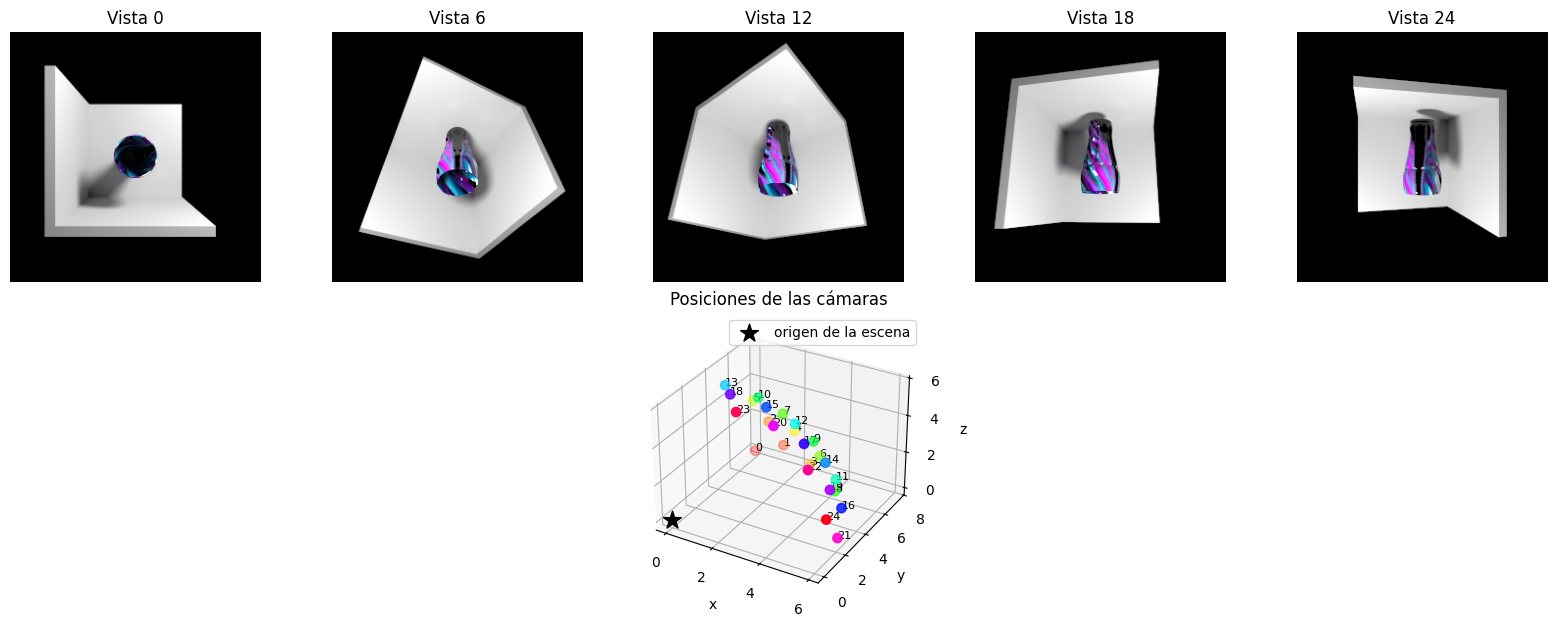

In [9]:
with h5py.File(SCENE_PATH, 'r') as f:
    images = f['images'][:]  # ~19 MiB para esta escena; es seguro cargarlo
    poses = np.asarray(f['poses'])

if poses.ndim == 4 and poses.shape[-1] == 1:
    poses = poses[..., 0]

# Normalización robusta común para no saturar por unos pocos valores altos.
display_scale = np.percentile(images, 99.5)
images_display = np.clip(images / max(display_scale, 1e-12), 0, 1) ** (1 / 2.2)
ids = np.linspace(0, n_views - 1, min(5, n_views), dtype=int)

fig = plt.figure(figsize=(16, 6), constrained_layout=True)
grid = fig.add_gridspec(2, len(ids), height_ratios=[1, 1.15])
for col, idx in enumerate(ids):
    ax = fig.add_subplot(grid[0, col])
    ax.imshow(images_display[idx])
    ax.set_title(f'Vista {idx}')
    ax.axis('off')

ax3d = fig.add_subplot(grid[1, :], projection='3d')
camera_xyz = poses[:, :3, 3]
ax3d.scatter(*camera_xyz.T, c=np.arange(n_views), cmap='hsv', s=45)
for idx in range(n_views):
    ax3d.text(*camera_xyz[idx], str(idx), fontsize=8)
ax3d.scatter(0, 0, 0, marker='*', s=180, c='black', label='origen de la escena')
ax3d.set(xlabel='x', ylabel='y', zlabel='z', title='Posiciones de las cámaras')
ax3d.legend()
plt.show()

## 4. Una vista y su dimensión temporal

Se selecciona inicialmente el píxel central de `VIEW_ID` y se lee solo su histograma. El pico indica el bin con mayor retorno; diferentes canales pueden tener distinta intensidad porque esta escena simulada es RGB. Cambie `VIEW_ID`, `PIXEL_Y` o `PIXEL_X` y vuelva a ejecutar la celda.

Vista 0, píxel (y=128, x=128), bin pico=549


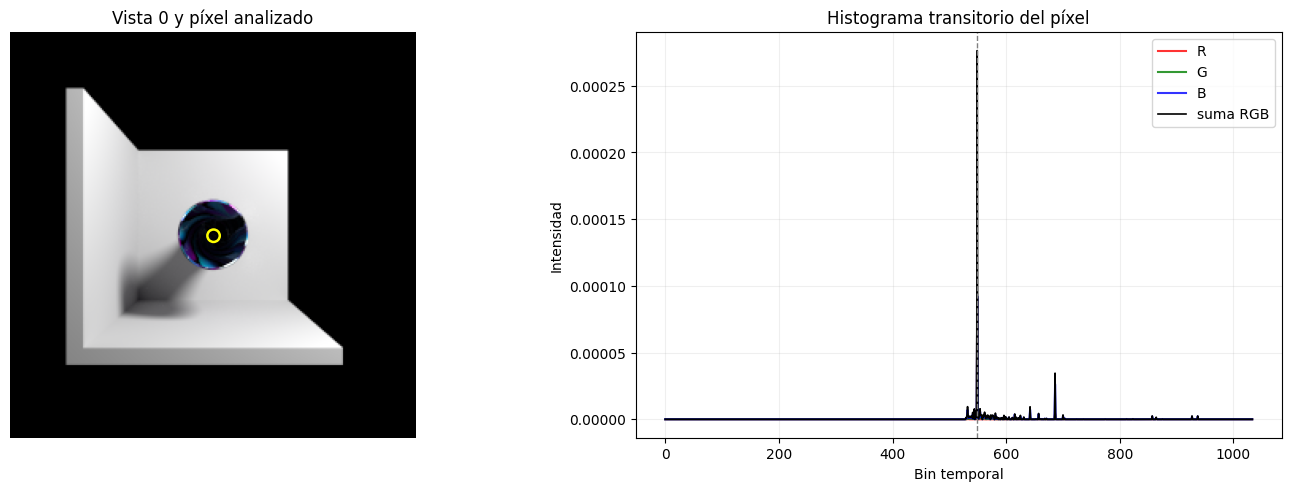

In [10]:
if not 0 <= VIEW_ID < n_views:
    raise IndexError(f'VIEW_ID debe estar entre 0 y {n_views - 1}')

PIXEL_Y, PIXEL_X = height // 2, width // 2  # coordenadas editables

with h5py.File(SCENE_PATH, 'r') as f:
    histogram = np.asarray(f['transients'][VIEW_ID, PIXEL_Y, PIXEL_X, :, :])

energy = histogram.sum(axis=-1)
peak_bin = int(energy.argmax())
print(f'Vista {VIEW_ID}, píxel (y={PIXEL_Y}, x={PIXEL_X}), bin pico={peak_bin}')

fig, (ax_image, ax_hist) = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
ax_image.imshow(images_display[VIEW_ID])
ax_image.scatter(PIXEL_X, PIXEL_Y, s=80, facecolors='none', edgecolors='yellow', linewidths=1.8)
ax_image.set_title(f'Vista {VIEW_ID} y píxel analizado')
ax_image.axis('off')

for channel, color in enumerate(('r', 'g', 'b')):
    ax_hist.plot(histogram[:, channel], color=color, alpha=0.8, label='RGB'[channel])
ax_hist.plot(energy, color='black', linewidth=1.2, label='suma RGB')
ax_hist.axvline(peak_bin, color='gray', linestyle='--', linewidth=1)
ax_hist.set(xlabel='Bin temporal', ylabel='Intensidad', title='Histograma transitorio del píxel')
ax_hist.grid(alpha=0.2)
ax_hist.legend()
plt.show()